# AI Applications in Cybersecurity — Jupyter Notebook

This notebook demonstrates practical applications of Artificial Intelligence (AI) in Cybersecurity using Python.
Each example includes an explanation, practical implementation, and visuals.

## Setup: Import Libraries

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB

## 1. Detecting Malicious Network Traffic

              precision    recall  f1-score   support

           0       0.25      0.05      0.08        66
           1       0.78      0.96      0.86       234

    accuracy                           0.76       300
   macro avg       0.52      0.50      0.47       300
weighted avg       0.66      0.76      0.69       300



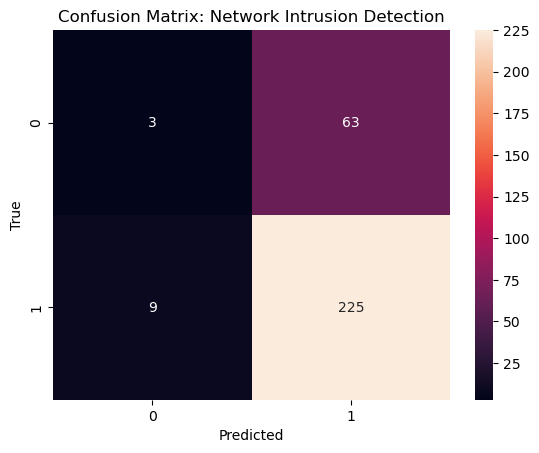

In [7]:
np.random.seed(42)
data = pd.DataFrame({
    "duration": np.random.randint(1, 1000, 1000),
    "src_bytes": np.random.randint(0, 100000, 1000),
    "dst_bytes": np.random.randint(0, 100000, 1000),
    "flag": np.random.choice(["SF", "REJ", "S0"], 1000),
    "label": np.random.choice(["normal", "malicious"], 1000, p=[0.8, 0.2])
})

le = LabelEncoder()
data["flag"] = le.fit_transform(data["flag"])
data["label"] = le.fit_transform(data["label"])

X = data.drop("label", axis=1)
y = data["label"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

model = RandomForestClassifier()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d")
plt.title("Confusion Matrix: Network Intrusion Detection")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()


## 2. Email Spam Detection Using Naive Bayes

In [10]:
emails = [
    "Win a free iPhone now! Click here",
    "Reminder: your invoice is due",
    "Congratulations! You have won a prize",
    "Let's schedule our meeting next week",
    "Earn money quickly from home",
    "Your Amazon order has been shipped"
]
labels = [1, 0, 1, 0, 1, 0]  # 1 = spam, 0 = not spam

vectorizer = CountVectorizer()
X = vectorizer.fit_transform(emails)
y = labels

spam_model = MultinomialNB()
spam_model.fit(X, y)

new_email = ["Claim your lottery prize now"]
new_X = vectorizer.transform(new_email)
predicted = spam_model.predict(new_X)

print("Prediction (1=spam, 0=not spam):", predicted[0])


Prediction (1=spam, 0=not spam): 1


## 3. Anomaly Detection in Login Patterns

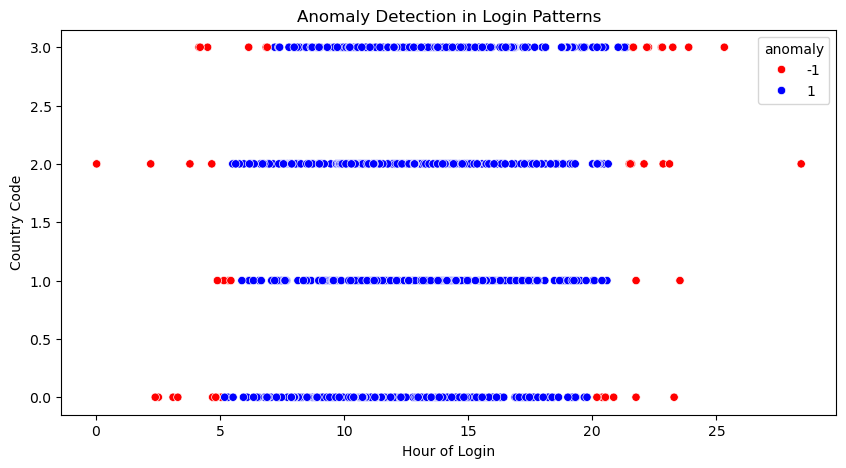

In [13]:
np.random.seed(42)
logins = pd.DataFrame({
    "hour": np.random.normal(13, 4, 1000),
    "country": np.random.choice(["US", "UK", "IN", "CN"], 1000)
})

le = LabelEncoder()
logins["country_code"] = le.fit_transform(logins["country"])
X = logins[["hour", "country_code"]]

iso = IsolationForest(contamination=0.05)
logins["anomaly"] = iso.fit_predict(X)

plt.figure(figsize=(10,5))
sns.scatterplot(data=logins, x="hour", y="country_code", hue="anomaly", palette={1: "blue", -1: "red"})
plt.title("Anomaly Detection in Login Patterns")
plt.xlabel("Hour of Login")
plt.ylabel("Country Code")
plt.show()


## End of Notebook